<a href="https://colab.research.google.com/github/aitoufkir-khadija2004/Exercise-Pose-Correction-_Module-AAI/blob/main/AAI_Exercise_Pose_Correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q mediapipe==0.10.13
!pip install -q opencv-python-headless kaggle
print("✅ Installation OK")


✅ Installation OK


In [2]:

import os, cv2, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
warnings.filterwarnings('ignore')


In [3]:

# Dossiers de travail
BASE = '/content/fitness_data'
for folder in ['videos/raw', 'processed', 'results']:
    os.makedirs(f'{BASE}/{folder}', exist_ok=True)

In [4]:

# Les 7 angles qu'on va calculer (= nos features)
ANGLE_NAMES = [
    'genou_gauche',   # Hanche G → Genou G → Cheville G
    'genou_droit',    # Hanche D → Genou D → Cheville D
    'hanche_gauche',  # Épaule G → Hanche G → Genou G
    'hanche_droite',  # Épaule D → Hanche D → Genou D
    'coude_gauche',   # Épaule G → Coude G → Poignet G
    'coude_droit',    # Épaule D → Coude D → Poignet D
    'tronc',          # Nez → Épaule G → Hanche G
]

In [5]:
# Téléchargement du modèle MediaPipe
print("📥 Téléchargement du modèle MediaPipe...")
urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task",
    "pose_landmarker.task"
)


# Création du détecteur
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options      = vision.PoseLandmarkerOptions(base_options=base_options)
detector     = vision.PoseLandmarker.create_from_options(options)

print("✅ Imports OK")
print("✅ MediaPipe détecteur OK")
print(f"📁 Dossiers créés dans {BASE}")


📥 Téléchargement du modèle MediaPipe...
✅ Imports OK
✅ MediaPipe détecteur OK
📁 Dossiers créés dans /content/fitness_data


In [7]:
# Configuration Kaggle
import os, json

KAGGLE_USERNAME = "khadijaaitoufkir"
KAGGLE_KEY      = "KGAT_1b1de71842f7a9624e3d649e105da702"

# Création du kaggle.json manuellement
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_config = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_config, f)

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print("✅ kaggle.json créé")

# Téléchargement du dataset
BASE = '/content/fitness_data'
print("\n📥 Téléchargement des vidéos...")
!kaggle datasets download -d hasyimabdillah/workoutfitness-video \
    -p {BASE}/videos/raw --unzip --quiet

print("\n📁 Vidéos disponibles :")
!find {BASE}/videos/raw -name "*.mp4" | wc -l
print("vidéos téléchargées")

✅ kaggle.json créé

📥 Téléchargement des vidéos...
Dataset URL: https://www.kaggle.com/datasets/hasyimabdillah/workoutfitness-video
License(s): CC-BY-NC-SA-4.0

📁 Vidéos disponibles :
590
vidéos téléchargées


In [8]:
import glob

all_videos = glob.glob(f'{BASE}/videos/raw/**/*.mp4', recursive=True)
print(f"Total vidéos : {len(all_videos)}\n")

for v in sorted(all_videos)[:15]:
    print(f"  {v.replace(f'{BASE}/videos/raw/', '')}")
if len(all_videos) > 15:
    print(f"  ... et {len(all_videos)-15} autres")

# Filtrage : on garde squat, pushup, lunge
video_map = {}
for v in all_videos:
    name   = os.path.basename(v).lower()
    folder = os.path.dirname(v).lower()
    for ex in ['squat', 'push_up', 'pushup', 'lunge']:
        if ex in name or ex in folder:
            clean = 'pushup' if 'push' in ex else ex
            video_map.setdefault(clean, []).append(v)
            break

print(f"\nVidéos par exercice :")
for ex, vids in video_map.items():
    print(f"  {ex:15s} : {len(vids)} vidéos")



Total vidéos : 590

  barbell biceps curl/barbell biceps curl_1.mp4
  barbell biceps curl/barbell biceps curl_10.mp4
  barbell biceps curl/barbell biceps curl_11.mp4
  barbell biceps curl/barbell biceps curl_12.mp4
  barbell biceps curl/barbell biceps curl_13.mp4
  barbell biceps curl/barbell biceps curl_14.mp4
  barbell biceps curl/barbell biceps curl_15.mp4
  barbell biceps curl/barbell biceps curl_16.mp4
  barbell biceps curl/barbell biceps curl_17.mp4
  barbell biceps curl/barbell biceps curl_18.mp4
  barbell biceps curl/barbell biceps curl_19.mp4
  barbell biceps curl/barbell biceps curl_2.mp4
  barbell biceps curl/barbell biceps curl_20.mp4
  barbell biceps curl/barbell biceps curl_21.mp4
  barbell biceps curl/barbell biceps curl_22.mp4
  ... et 575 autres

Vidéos par exercice :
  squat           : 23 vidéos


In [9]:

# Index des 33 landmarks MediaPipe
LM = {
    'nez':        0,
    'epaule_g':   11, 'epaule_d':   12,
    'coude_g':    13, 'coude_d':    14,
    'poignet_g':  15, 'poignet_d':  16,
    'hanche_g':   23, 'hanche_d':   24,
    'genou_g':    25, 'genou_d':    26,
    'cheville_g': 27, 'cheville_d': 28,
}

# 7 triplets (A, B, C) — B est le sommet de l'angle
ANGLE_TRIPLETS = [
    (LM['hanche_g'],  LM['genou_g'],  LM['cheville_g']),  # genou gauche
    (LM['hanche_d'],  LM['genou_d'],  LM['cheville_d']),  # genou droit
    (LM['epaule_g'],  LM['hanche_g'], LM['genou_g']),     # hanche gauche
    (LM['epaule_d'],  LM['hanche_d'], LM['genou_d']),     # hanche droite
    (LM['epaule_g'],  LM['coude_g'],  LM['poignet_g']),   # coude gauche
    (LM['epaule_d'],  LM['coude_d'],  LM['poignet_d']),   # coude droit
    (LM['nez'],       LM['epaule_g'], LM['hanche_g']),    # tronc
]

def calculate_angle(A, B, C):
    """Angle en degrés au sommet B entre BA et BC."""
    BA = A - B
    BC = C - B
    cos_a = np.dot(BA, BC) / (np.linalg.norm(BA) * np.linalg.norm(BC) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_a, -1.0, 1.0)))

def extract_angles_from_landmarks(landmarks):
    """
    landmarks : liste de NormalizedLandmark (nouvelle API MediaPipe)
    Retourne : array (7,) des angles en degrés
    """
    pts = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])
    return np.array([calculate_angle(pts[a], pts[b], pts[c])
                     for (a, b, c) in ANGLE_TRIPLETS])

# Test
A = np.array([0, 1, 0])
B = np.array([0, 0, 0])
C = np.array([1, 0, 0])
print(f"Test angle à 90° → {calculate_angle(A, B, C):.1f}°  ✅")


Test angle à 90° → 90.0°  ✅


In [10]:

SEQ_LEN = 60  # frames par séquence

def extract_sequences_from_video(video_path, seq_len=SEQ_LEN):
    """
    Extrait des séquences d'angles depuis une vidéo MP4.
    Retourne : liste de np.array (seq_len, 7)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []

    sequences   = []
    current_seq = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Conversion BGR → RGB pour MediaPipe
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect(mp_img)

        # Si des landmarks sont détectés
        if result.pose_landmarks and len(result.pose_landmarks) > 0:
            landmarks = result.pose_landmarks[0]  # première personne
            angles    = extract_angles_from_landmarks(landmarks)
            current_seq.append(angles)

            if len(current_seq) == seq_len:
                sequences.append(np.array(current_seq))
                current_seq = current_seq[30:]  # 50% overlap

    cap.release()
    return sequences


# Extraction de toutes les vidéos
print("🔄 Extraction des keypoints (5-10 minutes)...\n")

sequences_correct = []
labels_correct    = []
meta_correct      = []

for exercise, video_list in video_map.items():
    ex_seqs = 0
    for vpath in video_list:
        seqs = extract_sequences_from_video(vpath)
        for seq in seqs:
            sequences_correct.append(seq)
            labels_correct.append(0)  # 0 = CORRECT (coachs experts)
            meta_correct.append({
                'exercise':  exercise,
                'label':     0,
                'label_str': 'correct',
                'source':    'kaggle'
            })
            ex_seqs += 1
    print(f"  ✅ {exercise:15s} : {ex_seqs} séquences extraites")

print(f"\n  Total séquences correctes : {len(sequences_correct)}")



🔄 Extraction des keypoints (5-10 minutes)...

  ✅ squat           : 127 séquences extraites

  Total séquences correctes : 127


In [11]:

ERRORS = {
    'squat': {
        'genou_valgus':  {'indices': [0, 1], 'perturbation': -25, 'zone': 'bas'},
        'tronc_penche':  {'indices': [6],    'perturbation': -20, 'zone': 'partout'},
    },
    'pushup': {
        'hanches_affaissees': {'indices': [2, 3], 'perturbation': -25, 'zone': 'partout'},
        'tronc_casse':        {'indices': [6],     'perturbation': -20, 'zone': 'partout'},
    },
    'lunge': {
        'genou_en_avant': {'indices': [0], 'perturbation': -20, 'zone': 'bas'},
        'tronc_penche':   {'indices': [6], 'perturbation': -18, 'zone': 'partout'},
    },
}

def generate_incorrect(seq_correct, exercise, error_name):
    """
    Injecte une erreur biomécanique dans une séquence correcte.
    """
    seq = seq_correct.copy()
    error = ERRORS.get(exercise, {}).get(error_name)
    if not error:
        return seq

    for i in range(len(seq)):
        # Intensité : max au point bas (frame 30), nulle en position debout
        intensity = np.sin(np.pi * i / len(seq)) if error['zone'] == 'bas' else 1.0
        noise     = np.random.normal(0, 3)
        for idx in error['indices']:
            seq[i, idx] += error['perturbation'] * intensity + noise
            seq[i, idx]  = np.clip(seq[i, idx], 5, 175)
    return seq


print("🔄 Génération des séquences incorrectes...")
np.random.seed(42)

sequences_incorrect = []
labels_incorrect    = []
meta_incorrect      = []

for seq, meta_item in zip(sequences_correct, meta_correct):
    exercise = meta_item['exercise']
    for error_name in ERRORS.get(exercise, {}).keys():
        seq_bad = generate_incorrect(seq, exercise, error_name)
        sequences_incorrect.append(seq_bad)
        labels_incorrect.append(1)
        meta_incorrect.append({
            'exercise':  exercise,
            'label':     1,
            'label_str': 'incorrect',
            'source':    'generated',
            'erreur':    error_name,
        })

print(f"  ✅ Séquences incorrectes : {len(sequences_incorrect)}")


🔄 Génération des séquences incorrectes...
  ✅ Séquences incorrectes : 254


In [12]:
X    = np.array(sequences_correct + sequences_incorrect)
y    = np.array(labels_correct    + labels_incorrect)
meta = pd.DataFrame(meta_correct  + meta_incorrect)

print(f"Dataset brut : {X.shape}  |  Correct={np.sum(y==0)}  Incorrect={np.sum(y==1)}")

# Équilibrage si déséquilibre > 20%
n_min = min(np.sum(y==0), np.sum(y==1))
if abs(np.sum(y==0) - np.sum(y==1)) / len(y) > 0.2:
    idx_0 = np.where(y==0)[0][:n_min]
    idx_1 = np.where(y==1)[0][:n_min]
    idx   = np.concatenate([idx_0, idx_1])
    np.random.shuffle(idx)
    X, y, meta = X[idx], y[idx], meta.iloc[idx].reset_index(drop=True)
    print(f"⚖️  Équilibré à {n_min} par classe")

print(f"Dataset final : {X.shape}  |  Correct={np.sum(y==0)}  Incorrect={np.sum(y==1)}")



Dataset brut : (381, 60, 7)  |  Correct=127  Incorrect=254
⚖️  Équilibré à 127 par classe
Dataset final : (254, 60, 7)  |  Correct=127  Incorrect=127


In [13]:
from sklearn.preprocessing import StandardScaler

N, T, F = X.shape
scaler  = StandardScaler()
X_norm  = scaler.fit_transform(X.reshape(-1, F)).reshape(N, T, F)

print(f"Normalisation :")
print(f"  Avant : min={X.min():.1f}°  max={X.max():.1f}°  mean={X.mean():.1f}°")
print(f"  Après : min={X_norm.min():.2f}  max={X_norm.max():.2f}  mean={X_norm.mean():.3f}")


Normalisation :
  Avant : min=5.0°  max=179.7°  mean=111.7°
  Après : min=-4.41  max=2.81  mean=0.000


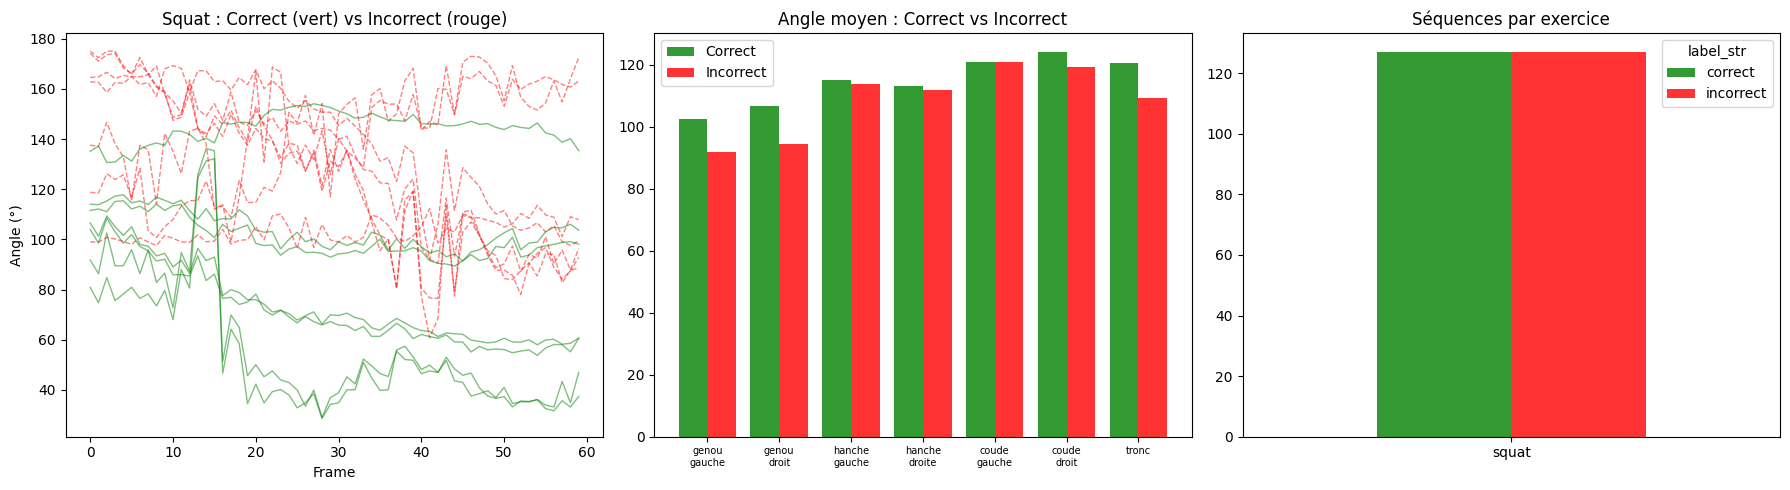

✅ EDA sauvegardée


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : séquence correcte vs incorrecte
idx_c = meta[(meta.exercise=='squat') & (meta.label==0)].index[0]
idx_i = meta[(meta.exercise=='squat') & (meta.label==1)].index[0]
for j in range(7):
    axes[0].plot(X[idx_c, :, j], color='green', alpha=0.5, lw=1)
    axes[0].plot(X[idx_i, :, j], color='red',   alpha=0.5, lw=1, linestyle='--')
axes[0].set_title('Squat : Correct (vert) vs Incorrect (rouge)')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Angle (°)')

# Graphique 2 : angle moyen par classe
X_mean  = X.mean(axis=1)
m_corr  = X_mean[y==0].mean(axis=0)
m_incr  = X_mean[y==1].mean(axis=0)
x_pos   = np.arange(7)
axes[1].bar(x_pos - 0.2, m_corr, 0.4, color='green', alpha=0.8, label='Correct')
axes[1].bar(x_pos + 0.2, m_incr, 0.4, color='red',   alpha=0.8, label='Incorrect')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([n.replace('_','\n') for n in ANGLE_NAMES], fontsize=7)
axes[1].set_title('Angle moyen : Correct vs Incorrect')
axes[1].legend()

# Graphique 3 : distribution par exercice
meta.groupby(['exercise','label_str']).size().unstack().plot(
    kind='bar', ax=axes[2], color=['green','red'], alpha=0.8
)
axes[2].set_title('Séquences par exercice')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{BASE}/results/eda_jour1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA sauvegardée")


In [15]:
np.save(f'{BASE}/processed/X.npy',    X_norm)
np.save(f'{BASE}/processed/y.npy',    y)
meta.to_csv(f'{BASE}/processed/meta.csv', index=False)
with open(f'{BASE}/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Fichiers sauvegardés dans /content/fitness_data/processed/")
print(f"   X.npy      : {X_norm.shape}")
print(f"   y.npy      : {y.shape}")
print(f"   meta.csv   : {len(meta)} lignes")
print(f"   scaler.pkl : StandardScaler (7 features)")


✅ Fichiers sauvegardés dans /content/fitness_data/processed/
   X.npy      : (254, 60, 7)
   y.npy      : (254,)
   meta.csv   : 254 lignes
   scaler.pkl : StandardScaler (7 features)
